**Bonus Question 4**

In [1]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/ladkevinkumar/group9-dsb/Gold 100years.csv
/kaggle/input/datasets/ladkevinkumar/group9-dsb/Brent Oil.csv
/kaggle/input/datasets/ladkevinkumar/group9-dsb/silver 100 years.csv
/kaggle/input/datasets/ladkevinkumar/group9-dsb/swift_currency_tracker_all_reports.csv


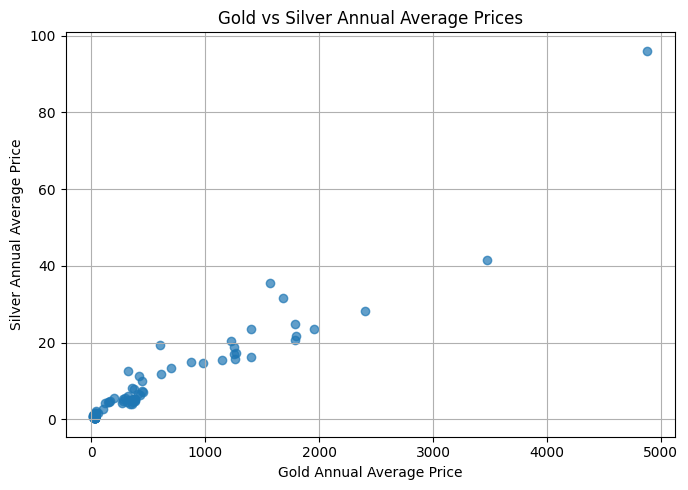

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

gold = pd.read_csv("/kaggle/input/datasets/ladkevinkumar/group9-dsb/Gold 100years.csv")
silver = pd.read_csv("/kaggle/input/datasets/ladkevinkumar/group9-dsb/silver 100 years.csv")

def prepare(df, name):
    df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)
    df["Value"] = pd.to_numeric(df["Value"], errors="coerce")
    df["Year"] = df["Date"].dt.year
    return df.groupby("Year")["Value"].mean().rename(name)

gold = prepare(gold, "Gold")
silver = prepare(silver, "Silver")

data = pd.concat([gold, silver], axis=1).dropna()

plt.figure(figsize=(7,5))
plt.scatter(data["Gold"], data["Silver"], alpha=0.7)
plt.title("Gold vs Silver Annual Average Prices")
plt.xlabel("Gold Annual Average Price")
plt.ylabel("Silver Annual Average Price")
plt.grid(True)

plt.tight_layout()
plt.savefig("Gold_vs_Silver_ScatterPlot.pdf", format="pdf")
plt.show()